머신러닝: K-Means <br>
신규기업 증가율, 외부유입 인구, 상권활력도, 프랜차이즈 수

In [281]:
import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [282]:
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "output"

df = pd.read_csv(DATA_DIR / "행정동_분기_마스터(최종).csv", encoding="utf-8-sig")

### (1) 신규기업 증가율

1. 증가율 계산

In [283]:
df_yoy = df[["adm_dong_cd", "adm_dong_nm", "year", "quarter",
             "base_quarter", "new_corp_cnt"]].copy()

# 동/연/분기 기준으로 정렬
df_yoy = df_yoy.sort_values(["adm_dong_cd", "year", "quarter"])

# (YoY 계산용) 동일한 분기끼리 1년 전 값 가져오기
df_yoy["new_corp_cnt_prev"] = (
    df_yoy.groupby(["adm_dong_cd", "quarter"])["new_corp_cnt"].shift(1)
)

# YoY 증가율 (%) — 분모 0/NaN 처리
df_yoy["new_corp_yoy"] = (
    (df_yoy["new_corp_cnt"] - df_yoy["new_corp_cnt_prev"])
    / df_yoy["new_corp_cnt_prev"]
) * 100

2. 전처리

In [284]:
# 2022년 대비 2023년 동 분기 증가율 확인 불가(NaN) 
# K-Means는 데이터 양/분포에 민감한 모델
# 중앙값으로 채울 경우 문제: YoY는 "변화율"이라 분포가 큼: "데이터 부재"로 인한 결측치인데 존재하지 않는 변화율을 만들어 평균적인 성장처럼 보이게 함(해석 왜곡)
# 데이터 보존 위해 값을 0("성장 없음")으로 채우되 yoy_missing으로 결측 여부 정보 추가 
df_yoy["yoy_missing"] = (
    df_yoy["new_corp_cnt_prev"].isna() |
    (df_yoy["new_corp_cnt_prev"] == 0)
).astype(int)

In [285]:
df_yoy["new_corp_yoy"] = df_yoy["new_corp_yoy"].replace([np.inf, -np.inf], np.nan)
#np.inf는 양의 무한대, -np.inf는 음의 무한대
#모델이 이해할 수 없는 무한대는 NaN로 처리

df_yoy["new_corp_yoy"] = df_yoy["new_corp_yoy"].fillna(0)

In [286]:
# 성능 개선(군집 분류 ↑) 위해 YoY(장기 변화) + QoQ(단기 변화)

df_yoy["new_corp_qoq"] = (
    df_yoy.groupby("adm_dong_cd")["new_corp_cnt"]
    .pct_change() * 100
) # pct_change(): 바로 이전 값 대비

df_yoy["qoq_missing"] = df_yoy["new_corp_qoq"].isnull().astype(int)
df_yoy["new_corp_qoq"] = df_yoy["new_corp_qoq"].replace([np.inf, -np.inf], np.nan)
df_yoy["new_corp_qoq"] = df_yoy["new_corp_qoq"].fillna(0)

3. 클러스터링

In [287]:
num_features = ["new_corp_yoy", "new_corp_qoq"]
cat_features = ["yoy_missing", "qoq_missing"]

scaler = StandardScaler()
X_scaled_num = scaler.fit_transform(df_yoy[num_features])

# 이진 변수는 그대로 사용
X_final = np.hstack([X_scaled_num, df_yoy[cat_features].values])

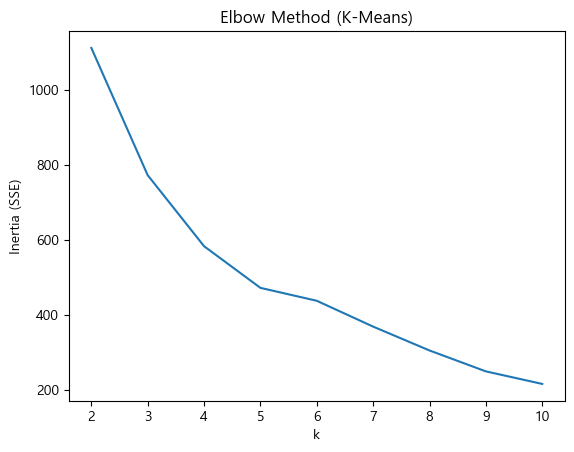

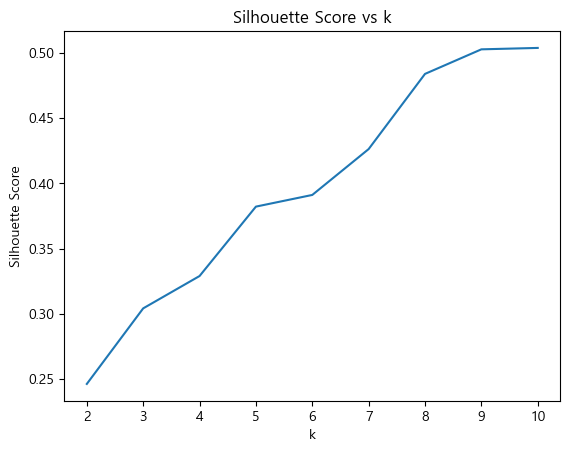

In [288]:
# k 값별 inertia & silhouette 계산
k_values = range(2, 11)
inertia_list = []
silhouette_list = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = model.fit_predict(X_final)

    inertia_list.append(model.inertia_)  # Elbow
    silhouette_list.append(silhouette_score(X_final, labels))

# 4) 시각화
plt.figure()
plt.plot(k_values, inertia_list)
plt.xlabel("k")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method (K-Means)")
plt.show()

plt.figure()
plt.plot(k_values, silhouette_list)
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show()

Explained variance ratio: [0.67322377 0.32677623]
총 설명 분산: 1.0


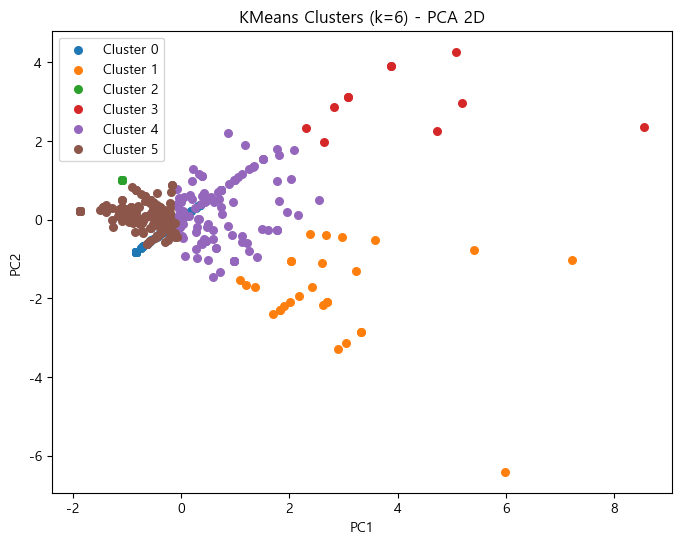

In [289]:
# 1) best_K 정하기
best_k = 6

# 2) best_k로 KMeans 학습
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_final)

# 3) PCA로 2차원 축소
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_num)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("총 설명 분산:", sum(pca.explained_variance_ratio_))

# 4) 시각화
plt.figure(figsize=(8, 6))

for cluster in np.unique(labels):
    plt.scatter(
        X_pca[labels == cluster, 0],
        X_pca[labels == cluster, 1],
        label=f"Cluster {cluster}",
        s=30
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"KMeans Clusters (k={best_k}) - PCA 2D")
plt.legend()
plt.show()

In [290]:
# 평가
sil = silhouette_score(X_final, labels)
dbi = davies_bouldin_score(X_final, labels)
ch = calinski_harabasz_score(X_final, labels)

print("Kmeans results")
print(f"n_cluster = {len(np.unique(labels))}")
print(f"Silhouette = {sil: .4f}")
print(f"DBI        = {dbi: .4f}")
print(f"CH Index   = {ch: .4f}")

Kmeans results
n_cluster = 6
Silhouette =  0.3912
DBI        =  0.8772
CH Index   =  268.0807


In [291]:
# Kmeans results
# n_cluster = 4
# Silhouette =  0.3291
# DBI        =  1.0050
# CH Index   =  286.4767

# Kmeans results
# n_cluster = 5
# Silhouette =  0.3822
# DBI        =  0.9950
# CH Index   =  300.2234

In [292]:
df_yoy["cluster"] = labels

profile = (df_yoy.groupby("cluster")
                 .agg(n=("new_corp_yoy", "size"),
                      yoy_mean=("new_corp_yoy", "mean"),
                      yoy_med=("new_corp_yoy", "median"),
                      qoq_mean=("new_corp_qoq", "mean"),
                      qoq_med=("new_corp_qoq", "median"),
                      yoy_miss_ratio=("yoy_missing", "mean"),
                      qoq_miss_ratio=("qoq_missing", "mean"))
                 .round(2))
print(profile)

# 동·분기 분포
print(df_yoy.groupby(["cluster", "year"]).size().unstack(fill_value=0))

           n  yoy_mean  yoy_med  qoq_mean  qoq_med  yoy_miss_ratio  \
cluster                                                              
0        239      0.00      0.0    -20.51     0.00            1.00   
1         28    227.45    200.0     62.70    33.33            0.00   
2         15   -100.00   -100.0      0.00     0.00            0.00   
3         11     54.70      0.0    458.33   450.00            0.55   
4        137     21.98      0.0     57.41    40.91            0.18   
5        170    -45.71    -50.0    -39.58   -40.83            0.00   

         qoq_miss_ratio  
cluster                  
0                  0.31  
1                  0.00  
2                  1.00  
3                  0.00  
4                  0.00  
5                  0.00  
year     2023  2024  2025
cluster                  
0         178    32    29
1           0    18    10
2           0     5    10
3           5     2     4
4          17    58    62
5           0    85    85


In [293]:
df_filtered = df_yoy[df_yoy["cluster"] != 0].copy()

num_features = ["new_corp_yoy", "new_corp_qoq"]
cat_features = ["yoy_missing", "qoq_missing"]

scaler = StandardScaler()
X_scaled_num = scaler.fit_transform(df_filtered[num_features])

X_final = np.hstack([X_scaled_num, df_filtered[cat_features].values])

kmeans = KMeans(n_clusters=5, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_final)

df_filtered["cluster"] = labels

print("Silhouette:", silhouette_score(X_final, labels))
print("DBI:", davies_bouldin_score(X_final, labels))
print("CH:", calinski_harabasz_score(X_final, labels))


Silhouette: 0.36060449758724394
DBI: 0.8622857106575601
CH: 255.12824891562428


In [294]:
profile = (
    df_filtered.groupby("cluster")
    .agg(
        n=("new_corp_yoy", "size"),
        yoy_mean=("new_corp_yoy", "mean"),
        qoq_mean=("new_corp_qoq", "mean"),
    )
)
print(profile)

           n    yoy_mean    qoq_mean
cluster                             
0        138  -65.312407  -37.810761
1         26  224.615385   53.055556
2         10   96.833333  484.166667
3        130   16.925769   -4.297258
4         57   12.555455  131.386542


### (2) 외부유입 인구

1. 증가율

In [317]:
df_in = df[["adm_dong_cd", "adm_dong_nm", "year", "quarter",
            "base_quarter", "external_inflow"]].copy()

df_in = df_in.sort_values(["adm_dong_cd", "year", "quarter"])

df_in["inflow_prev"] = (
    df_in.groupby(["adm_dong_cd", "quarter"])["external_inflow"].shift(1)
)

df_in["inflow_yoy"] = (
    (df_in["external_inflow"] - df_in["inflow_prev"]) / df_in["inflow_prev"]
) * 100

2. 전처리

In [318]:
df_in["yoy_missing"] = (
    df_in["inflow_prev"].isna() | (df_in["inflow_prev"] == 0)
).astype(int)

df_in["inflow_yoy"] = df_in["inflow_yoy"].replace([np.inf, -np.inf], np.nan)
df_in["inflow_yoy"] = df_in["inflow_yoy"].fillna(0)

In [319]:
df_in["inflow_qoq"] = (
    df_in.groupby("adm_dong_cd")["external_inflow"].pct_change() * 100
)
df_in["qoq_missing"] = df_in["inflow_qoq"].isnull().astype(int)
df_in["inflow_qoq"] = df_in["inflow_qoq"].replace([np.inf, -np.inf], np.nan)
df_in["inflow_qoq"] = df_in["inflow_qoq"].fillna(0)

3. 클러스터링

In [321]:
num_features = ["inflow_yoy", "inflow_qoq"]
cat_features = ["yoy_missing", "qoq_missing"]

scaler = StandardScaler()
X_scaled_num = scaler.fit_transform(df_in[num_features])

X_final = np.hstack([X_scaled_num, df_in[cat_features].values])

scaler = StandardScaler()
X_scaled_num = scaler.fit_transform(df_in[num_features])

X_final = np.hstack([X_scaled_num, df_in[cat_features].values])

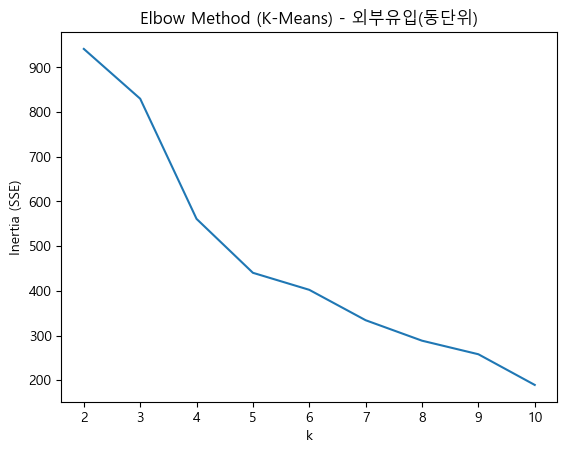

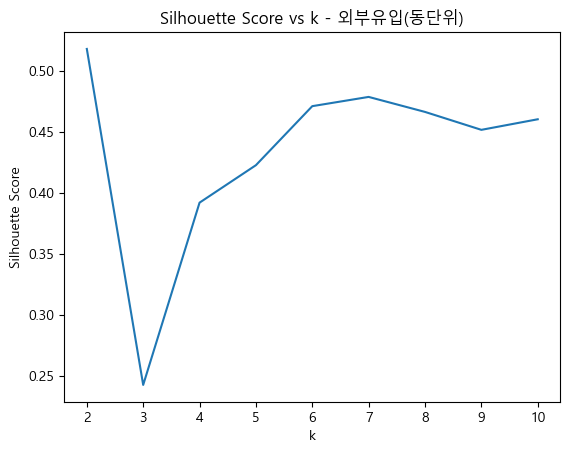

In [322]:
k_values = range(2, 11)
inertia_list = []
silhouette_list = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = model.fit_predict(X_final)
    inertia_list.append(model.inertia_)
    silhouette_list.append(silhouette_score(X_final, labels))

plt.figure()
plt.plot(k_values, inertia_list)
plt.xlabel("k"); plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method (K-Means) - 외부유입(동단위)")
plt.show()

plt.figure()
plt.plot(k_values, silhouette_list)
plt.xlabel("k"); plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k - 외부유입(동단위)")
plt.show()

Explained variance ratio: [0.68572171 0.31427829]
총 설명 분산: 1.0


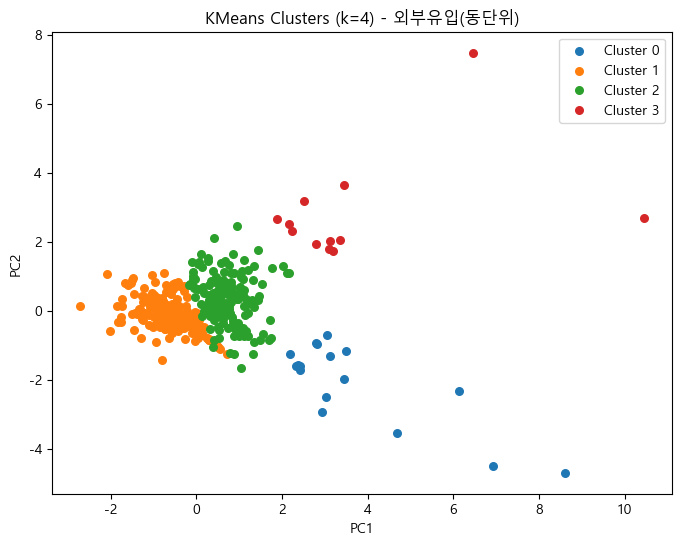

In [334]:
best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_final)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_num)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("총 설명 분산:", sum(pca.explained_variance_ratio_))

plt.figure(figsize=(8, 6))
for cluster in np.unique(labels):
    plt.scatter(
        X_pca[labels == cluster, 0],
        X_pca[labels == cluster, 1],
        label=f"Cluster {cluster}",
        s=30
    )
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"KMeans Clusters (k={best_k}) - 외부유입(동단위)")
plt.legend()
plt.show()

In [335]:
sil = silhouette_score(X_final, labels)
dbi = davies_bouldin_score(X_final, labels)
ch  = calinski_harabasz_score(X_final, labels)

print("Kmeans results - 외부유입 인구 증가율")
print(f"n_cluster = {len(np.unique(labels))}")
print(f"Silhouette = {sil: .4f}")
print(f"DBI        = {dbi: .4f}")
print(f"CH Index   = {ch: .4f}")

Kmeans results - 외부유입 인구 증가율
n_cluster = 4
Silhouette =  0.3919
DBI        =  0.9240
CH Index   =  289.7291


In [ ]:
# Kmeans results - 외부유입 인구 증가율
# n_cluster = 4
# Silhouette =  0.3919
# DBI        =  0.9240
# CH Index   =  289.7291

# Kmeans results - 외부유입 인구 증가율
# n_cluster = 5
# Silhouette =  0.4226
# DBI        =  0.8804
# CH Index   =  317.1409

# Kmeans results - 외부유입 인구 증가율
# n_cluster = 6
# Silhouette =  0.4709
# DBI        =  0.7580
# CH Index   =  288.5303

(3) 상권활력도

In [348]:
# 1. 전체 개폐업 점포 수
total_open_sum  = df['open_cnt'].sum()
total_close_sum = df['close_cnt'].sum()

# 2. 동별(prefix) 개업 점포 수의 합계
df_open  = df.groupby(['adm_dong_cd', 'adm_dong_nm', 'base_quarter'])['open_cnt'].sum().reset_index()
df_close = df.groupby(['adm_dong_cd', 'adm_dong_nm', 'base_quarter'])['close_cnt'].sum().reset_index()

# 3. 비중(Ratio)을 계산 (동별 합계 / 전체 합계)
df_open['open_ratio']   = (df_open['open_cnt']   / total_open_sum)  * 100
df_close['close_ratio'] = (df_close['close_cnt'] / total_close_sum) * 100

df_pct = df_open.merge(df_close, on=['adm_dong_cd', 'adm_dong_nm', 'base_quarter'], how='inner')
df_pct['mkt_vital'] = df_pct['open_ratio'] - df_pct['close_ratio']

In [349]:
def trend_slope(s):
    x = np.arange(len(s))
    return np.polyfit(x, s.values, 1)[0] if len(s) > 1 else 0

agg_mkt = (
    df_pct.sort_values("base_quarter")
          .groupby(["adm_dong_cd", "adm_dong_nm"])["mkt_vital"]
          .agg(mean="mean", std="std", median="median",
               p90=lambda s: s.quantile(0.9),
               slope=trend_slope)
          .reset_index()
          .fillna(0)
)

features = ["mean", "std", "median", "p90", "slope"]
X_final = StandardScaler().fit_transform(agg_mkt[features])

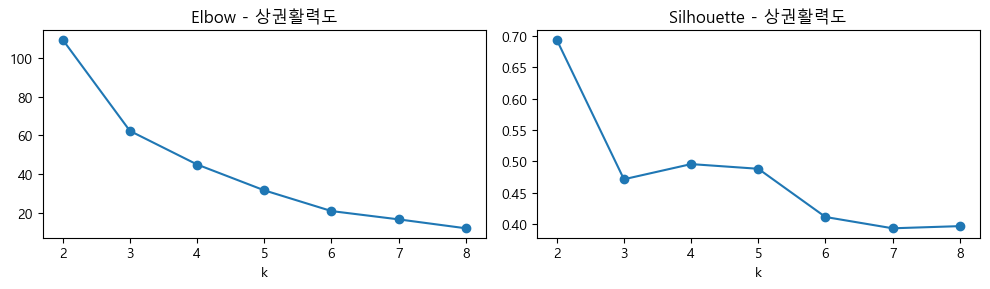

In [350]:
ks = range(2, 9)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(list(ks), inertias, "o-"); ax[0].set_title("Elbow - 상권활력도"); ax[0].set_xlabel("k")
ax[1].plot(list(ks), sils, "o-");     ax[1].set_title("Silhouette - 상권활력도"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.show()

In [352]:
k = 4
agg_mkt["cluster"] = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)

sil = silhouette_score(X, agg_mkt["cluster"])
dbi = davies_bouldin_score(X, agg_mkt["cluster"])
ch  = calinski_harabasz_score(X, agg_mkt["cluster"])
print("Kmeans results - 상권활력도(동단위)")
print(f"n_cluster = {k}")
print(f"Silhouette = {sil: .4f}")
print(f"DBI        = {dbi: .4f}")
print(f"CH Index   = {ch: .4f}")

Kmeans results - 상권활력도(동단위)
n_cluster = 4
Silhouette =  0.4959
DBI        =  0.6723
CH Index   =  52.7607


In [ ]:
# Kmeans results - 상권활력도(동단위)
# n_cluster = 3
# Silhouette =  0.4718
# DBI        =  0.7105
# CH Index   =  51.8725

In [353]:
profile = agg_mkt.groupby("cluster")[features].mean().round(2)
print(profile)

         mean   std  median   p90  slope
cluster                                 
0        0.00  0.05    0.01  0.05    0.0
1        0.00  0.04   -0.00  0.05    0.0
2       -0.01  0.04   -0.00  0.04    0.0
3        0.01  0.06    0.01  0.07    0.0


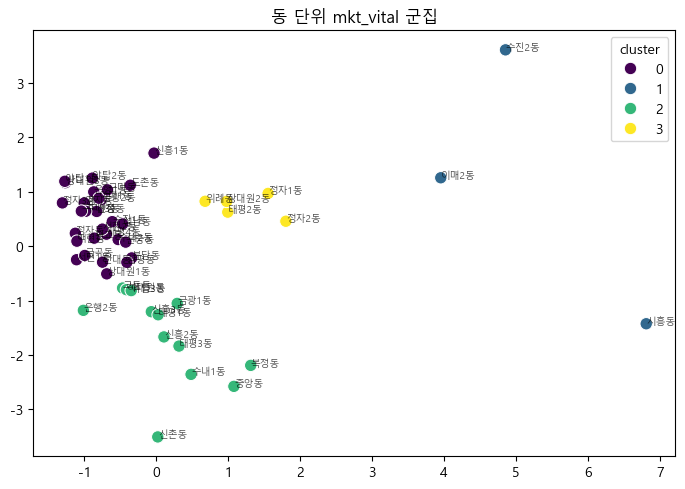

In [354]:
coords = PCA(n_components=2, random_state=42).fit_transform(X)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1],
                hue=agg_mkt["cluster"], palette="viridis", s=80)

for i, name in enumerate(agg_mkt["adm_dong_nm"]):
    plt.annotate(name, (coords[i, 0], coords[i, 1]), fontsize=7, alpha=0.7)

plt.title("동 단위 mkt_vital 군집")
plt.tight_layout(); plt.show()

(4) 프랜차이즈

1. 증가율 계산

In [339]:
df_fc = df[["adm_dong_cd", "adm_dong_nm", "year", "quarter",
            "base_quarter", "franchise_cnt"]].copy()
df_fc = df_fc.sort_values(["adm_dong_cd", "year", "quarter"])

df_fc["franchise_cnt_prev"] = (
    df_fc.groupby(["adm_dong_cd", "quarter"])["franchise_cnt"].shift(1)
)

df_fc["franchise_yoy"] = (
    (df_fc["franchise_cnt"] - df_fc["franchise_cnt_prev"]) / df_fc["franchise_cnt_prev"]
) * 100

2. 전처리

In [341]:
df_fc["yoy_missing"] = (
    df_fc["franchise_cnt_prev"].isna() | (df_fc["franchise_cnt_prev"] == 0)
).astype(int)

df_fc["franchise_yoy"] = df_fc["franchise_yoy"].replace([np.inf, -np.inf], np.nan)
df_fc["franchise_yoy"] = df_fc["franchise_yoy"].fillna(0)

In [342]:
agg_fc = (
    df_fc.sort_values("base_quarter")
         .groupby(["adm_dong_cd", "adm_dong_nm"])["franchise_yoy"]
         .agg(mean="mean", std="std", median="median",
              p90=lambda s: s.quantile(0.9),
              slope=trend_slope)
         .reset_index()
         .fillna(0)
)

3. 클러스터링

In [343]:
features = ["mean", "std", "median", "p90", "slope"]
X_final = StandardScaler().fit_transform(agg_fc[features])

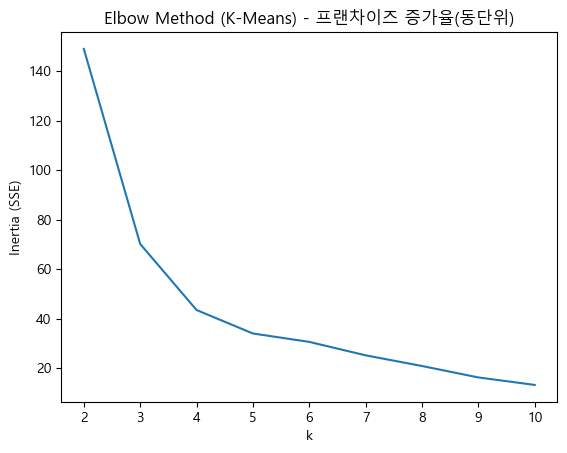

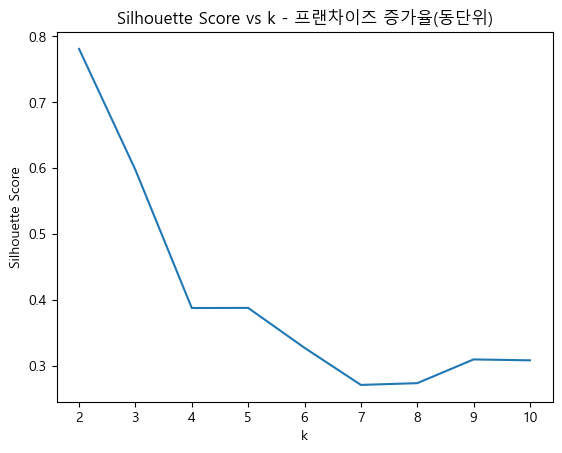

In [344]:
k_values = range(2, 11)
inertia_list = []
silhouette_list = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = model.fit_predict(X_final)
    inertia_list.append(model.inertia_)
    silhouette_list.append(silhouette_score(X_final, labels))

plt.figure()
plt.plot(k_values, inertia_list)
plt.xlabel("k"); plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method (K-Means) - 프랜차이즈 증가율(동단위)")
plt.show()

plt.figure()
plt.plot(k_values, silhouette_list)
plt.xlabel("k"); plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k - 프랜차이즈 증가율(동단위)")
plt.show()

Explained variance ratio: [0.7274139  0.21347521]
총 설명 분산: 0.940889117449832


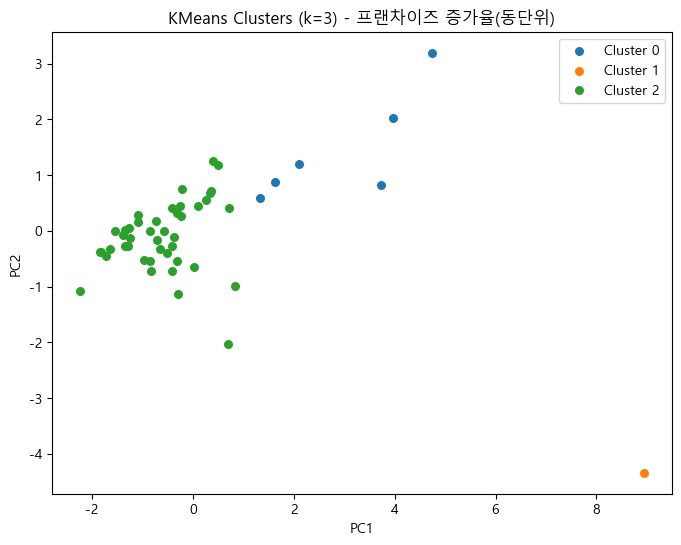

In [345]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_final)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_final)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("총 설명 분산:", sum(pca.explained_variance_ratio_))

plt.figure(figsize=(8, 6))
for cluster in np.unique(labels):
    plt.scatter(
        X_pca[labels == cluster, 0],
        X_pca[labels == cluster, 1],
        label=f"Cluster {cluster}",
        s=30
    )
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"KMeans Clusters (k={best_k}) - 프랜차이즈 증가율(동단위)")
plt.legend()
plt.show()

In [346]:
sil = silhouette_score(X_final, labels)
dbi = davies_bouldin_score(X_final, labels)
ch  = calinski_harabasz_score(X_final, labels)

print("Kmeans results - 프랜차이즈 증가율(동단위)")
print(f"n_cluster = {len(np.unique(labels))}")
print(f"Silhouette = {sil: .4f}")
print(f"DBI        = {dbi: .4f}")
print(f"CH Index   = {ch: .4f}")

Kmeans results - 프랜차이즈 증가율(동단위)
n_cluster = 3
Silhouette =  0.5974
DBI        =  0.5230
CH Index   =  60.1998


In [347]:
agg_fc["cluster"] = labels

profile = agg_fc.groupby("cluster")[features].mean().round(2)
print(profile)
print()

for c in sorted(agg_fc["cluster"].unique()):
    dongs = agg_fc.loc[agg_fc["cluster"] == c, "adm_dong_nm"].tolist()
    print(f"[Cluster {c}] {len(dongs)}개: {', '.join(dongs)}")

          mean    std  median    p90  slope
cluster                                    
0         9.99   9.79    9.07  21.66   1.28
1        29.84  38.86    1.90  87.52   1.40
2         0.61   5.16    0.21   6.55  -0.31

[Cluster 0] 6개: 신흥2동, 태평4동, 시흥동, 상대원1동, 서현1동, 백현동
[Cluster 1] 1개: 정자1동
[Cluster 2] 43개: 신흥1동, 신흥3동, 태평1동, 태평2동, 태평3동, 수진1동, 수진2동, 단대동, 산성동, 양지동, 복정동, 위례동, 신촌동, 고등동, 성남동, 중앙동, 금광1동, 금광2동, 은행1동, 은행2동, 상대원2동, 상대원3동, 하대원동, 도촌동, 분당동, 수내1동, 수내2동, 수내3동, 정자동, 정자2동, 정자3동, 서현2동, 이매1동, 이매2동, 야탑1동, 야탑2동, 야탑3동, 판교동, 삼평동, 금곡동, 구미1동, 구미동, 운중동


### (5) 젠트리피케이션 위험 군집 — 신규기업·프랜차이즈·외부유입 증가율 + 상권활력도

1. 증가율 계산

In [355]:
# 신규기업 증가율
df_new = df[["adm_dong_cd", "adm_dong_nm", "year", "quarter",
             "base_quarter", "new_corp_cnt"]].copy()
df_new = df_new.sort_values(["adm_dong_cd", "year", "quarter"])

df_new["new_corp_prev"] = (
    df_new.groupby(["adm_dong_cd", "quarter"])["new_corp_cnt"].shift(1)
)
df_new["new_corp_yoy"] = (
    (df_new["new_corp_cnt"] - df_new["new_corp_prev"]) / df_new["new_corp_prev"]
) * 100

# 프랜차이즈 증가율
df_fr = df[["adm_dong_cd", "adm_dong_nm", "year", "quarter",
            "base_quarter", "franchise_cnt"]].copy()
df_fr = df_fr.sort_values(["adm_dong_cd", "year", "quarter"])

df_fr["franchise_prev"] = (
    df_fr.groupby(["adm_dong_cd", "quarter"])["franchise_cnt"].shift(1)
)
df_fr["franchise_yoy"] = (
    (df_fr["franchise_cnt"] - df_fr["franchise_prev"]) / df_fr["franchise_prev"]
) * 100

# 외부유입 인구 증가율
df_inf = df[["adm_dong_cd", "adm_dong_nm", "year", "quarter",
             "base_quarter", "external_inflow"]].copy()
df_inf = df_inf.sort_values(["adm_dong_cd", "year", "quarter"])

df_inf["inflow_prev"] = (
    df_inf.groupby(["adm_dong_cd", "quarter"])["external_inflow"].shift(1)
)
df_inf["inflow_yoy"] = (
    (df_inf["external_inflow"] - df_inf["inflow_prev"]) / df_inf["inflow_prev"]
) * 100

In [356]:
# 상권 활력도
total_open  = df["open_cnt"].sum()
total_close = df["close_cnt"].sum()

df_mkt = (df.groupby(["adm_dong_cd", "adm_dong_nm", "base_quarter"])
            .agg(open_cnt=("open_cnt", "sum"),
                 close_cnt=("close_cnt", "sum"))
            .reset_index())

df_mkt["open_ratio"]  = df_mkt["open_cnt"]  / total_open  * 100
df_mkt["close_ratio"] = df_mkt["close_cnt"] / total_close * 100
df_mkt["mkt_vital"]   = df_mkt["open_ratio"] - df_mkt["close_ratio"]


2. 전처리

In [357]:
# 신규기업
df_new["new_corp_missing"] = (
    df_new["new_corp_prev"].isna() | (df_new["new_corp_prev"] == 0)
).astype(int)
df_new["new_corp_yoy"] = (df_new["new_corp_yoy"]
                            .replace([np.inf, -np.inf], np.nan).fillna(0))

# 프랜차이즈
df_fr["franchise_missing"] = (
    df_fr["franchise_prev"].isna() | (df_fr["franchise_prev"] == 0)
).astype(int)
df_fr["franchise_yoy"] = (df_fr["franchise_yoy"]
                            .replace([np.inf, -np.inf], np.nan).fillna(0))

# 외부유입
df_inf["inflow_missing"] = (
    df_inf["inflow_prev"].isna() | (df_inf["inflow_prev"] == 0)
).astype(int)
df_inf["inflow_yoy"] = (df_inf["inflow_yoy"]
                          .replace([np.inf, -np.inf], np.nan).fillna(0))


3. 통합 데이터프레임

In [358]:
df_gent = (
    df_new[["adm_dong_cd", "adm_dong_nm", "base_quarter",
            "new_corp_yoy", "new_corp_missing"]]
    .merge(df_fr[["adm_dong_cd", "base_quarter",
                  "franchise_yoy", "franchise_missing"]],
           on=["adm_dong_cd", "base_quarter"], how="inner")
    .merge(df_inf[["adm_dong_cd", "base_quarter",
                   "inflow_yoy", "inflow_missing"]],
           on=["adm_dong_cd", "base_quarter"], how="inner")
    .merge(df_mkt[["adm_dong_cd", "base_quarter", "mkt_vital"]],
           on=["adm_dong_cd", "base_quarter"], how="inner")
)

print(df_gent.shape)
df_gent.head()


(600, 10)


,adm_dong_cd,adm_dong_nm,base_quarter,new_corp_yoy,new_corp_missing,franchise_yoy,franchise_missing,inflow_yoy,inflow_missing,mkt_vital
0,41131510,신흥1동,2023Q1,0.0,1,0.000000,1,0.000000,1,-0.031980
1,41131510,신흥1동,2023Q2,0.0,1,0.000000,1,0.000000,1,-0.036254
2,41131510,신흥1동,2023Q3,0.0,1,0.000000,1,0.000000,1,-0.135950
3,41131510,신흥1동,2023Q4,0.0,1,0.000000,1,0.000000,1,-0.058389
4,41131510,신흥1동,2024Q1,-100.0,0,8.189655,0,-5.763744,0,-0.038189


4. 클러스터링

In [359]:
num_features = ["new_corp_yoy", "franchise_yoy", "inflow_yoy", "mkt_vital"]
cat_features = ["new_corp_missing", "franchise_missing", "inflow_missing"]

scaler = StandardScaler()
X_scaled_num = scaler.fit_transform(df_gent[num_features])

X_final = np.hstack([X_scaled_num, df_gent[cat_features].values])


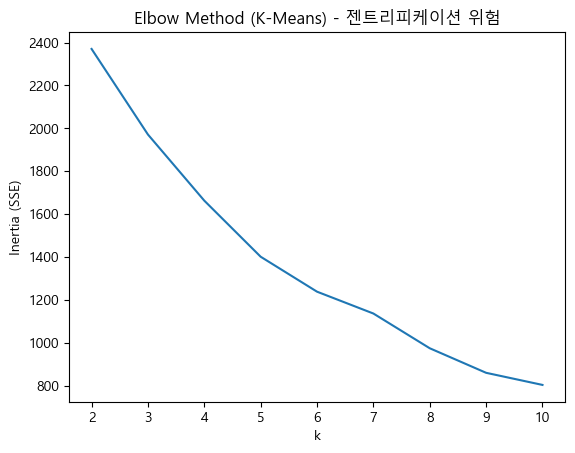

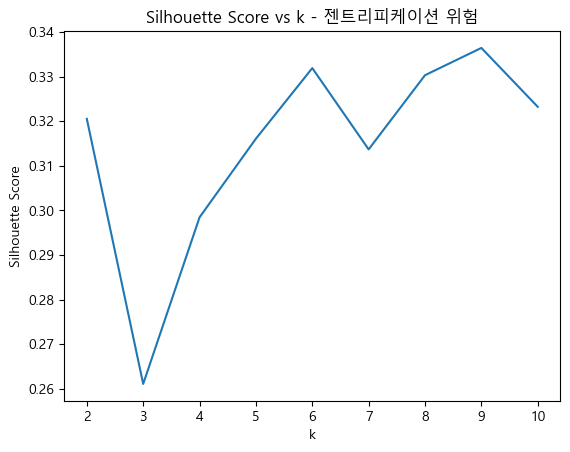

In [360]:
k_values = range(2, 11)
inertia_list = []
silhouette_list = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = model.fit_predict(X_final)
    inertia_list.append(model.inertia_)
    silhouette_list.append(silhouette_score(X_final, labels))

plt.figure()
plt.plot(k_values, inertia_list)
plt.xlabel("k")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method (K-Means) - 젠트리피케이션 위험")
plt.show()

plt.figure()
plt.plot(k_values, silhouette_list)
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k - 젠트리피케이션 위험")
plt.show()


Explained variance ratio: [0.32076958 0.25614204]
총 설명 분산: 0.5769116186888241


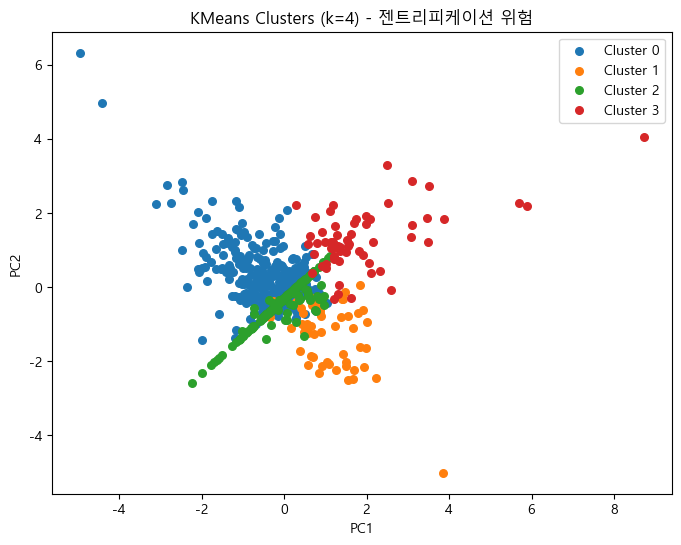

In [391]:
best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_final)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_num)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("총 설명 분산:", sum(pca.explained_variance_ratio_))

plt.figure(figsize=(8, 6))
for cluster in np.unique(labels):
    plt.scatter(
        X_pca[labels == cluster, 0],
        X_pca[labels == cluster, 1],
        label=f"Cluster {cluster}",
        s=30
    )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"KMeans Clusters (k={best_k}) - 젠트리피케이션 위험")
plt.legend()
plt.show()


In [379]:
sil = silhouette_score(X_final, labels)
dbi = davies_bouldin_score(X_final, labels)
ch  = calinski_harabasz_score(X_final, labels)

print("Kmeans results - 젠트리피케이션 위험")
print(f"n_cluster = {len(np.unique(labels))}")
print(f"Silhouette = {sil: .4f}")
print(f"DBI        = {dbi: .4f}")
print(f"CH Index   = {ch: .4f}")

Kmeans results - 젠트리피케이션 위험
n_cluster = 4
Silhouette =  0.2984
DBI        =  1.2907
CH Index   =  137.6589


In [ ]:
# Kmeans results - 젠트리피케이션 위험
# n_cluster = 4
# Silhouette =  0.2984
# DBI        =  1.2907
# CH Index   =  137.6589

# Kmeans results - 젠트리피케이션 위험
# n_cluster = 5
# Silhouette =  0.3161
# DBI        =  1.2295
# CH Index   =  150.0596

# Kmeans results - 젠트리피케이션 위험
# n_cluster = 6
# Silhouette =  0.3319
# DBI        =  1.1049
# CH Index   =  151.2611

In [380]:
df_gent["cluster"] = labels

profile = (df_gent.groupby("cluster")
                  .agg(n=("new_corp_yoy", "size"),
                       new_corp_yoy=("new_corp_yoy", "mean"),
                       franchise_yoy=("franchise_yoy", "mean"),
                       inflow_yoy=("inflow_yoy", "mean"),
                       mkt_vital=("mkt_vital", "mean"),
                       new_corp_miss=("new_corp_missing", "mean"),
                       franchise_miss=("franchise_missing", "mean"),
                       inflow_miss=("inflow_missing", "mean"))
                  .round(2))
print(profile)
print()

# cluster별 분기 분포
print(df_gent.groupby(["cluster", "base_quarter"]).size().unstack(fill_value=0))

           n  new_corp_yoy  franchise_yoy  inflow_yoy  mkt_vital  \
cluster                                                            
0        259        -29.49           0.19       25.58      -0.01   
1         53        168.46           2.52        5.36       0.01   
2        229          0.07           0.21       -1.70      -0.02   
3         59        -10.10          19.70        6.78       0.11   

         new_corp_miss  franchise_miss  inflow_miss  
cluster                                              
0                 0.13            0.00         0.00  
1                 0.00            0.00         0.00  
2                 0.99            0.85         0.85  
3                 0.19            0.08         0.08  

base_quarter  2023Q1  2023Q2  2023Q3  2023Q4  2024Q1  2024Q2  2024Q3  2024Q4  \
cluster                                                                        
0                  0       0       0       0      33      10      20      30   
1                  0      